# Noise2Noise (N2N) with diffusion Ã¢â‚¬â€ general MRI denoise

A self-contained walk-through of a **Noise2Noise (Lehtinen et al. 2018)**
denoiser mounted on the diffusion stack in this folder (`ddpm.py` / `dsm.py` /
`unet.py` / `train.py` / `di_n2n.py`).

**The motivating constraint:** only NOISY images are available Ã¢â‚¬â€ there is no
clean high-SNR reference, so a standard supervised (noisy Ã¢â€ â€™ clean) denoiser is
unavailable. N2N needs only two **independent noisy realizations** of the same
object: a network trained to map realizationÃ¢â€šÂ Ã¢â€ â€™ realizationÃ¢â€šâ€š learns the clean
image **in expectation**.

This notebook treats denoising as a **general MRI denoise task**, agnostic to
any specific acquisition/application: it uses **complex additive Gaussian noise**
with no magnitude-domain / Rician assumption. The clean phantom `gt` is used
**only for validation**, never during training.

Cells are independent: run them top-to-bottom. Training reuses the shared
`UNet`, `DDPM`, `DSM`, `DiffusionTrainer`, and the new `N2N_DDPM` / `N2N_DSM`
objectives from this folder.

## Setup

In [27]:
import sys, os
from pathlib import Path

# Make the `diffusion` folder importable from either this notebook dir or its parent.
DIFF = Path(os.getcwd())
if DIFF.name != "diffusion":
    DIFF = DIFF / "diffusion"
if str(DIFF) not in sys.path:
    sys.path.insert(0, str(DIFF))

import numpy as np
import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

device: cuda


### Module reload (run after editing any of the `.py` library files)

Python caches a module after first import, so stale definitions persist across
cells. `importlib.reload()` forces a fresh re-read, then re-imports pull the new
classes. `di_n2n.py` is new this session Ã¢â‚¬â€ reload it alongside the modules it
depends on (`unet`, `ddpm`, `dsm`, `train`).

In [67]:
import importlib
import unet, ddpm, dsm, train, n2n
importlib.reload(unet)
importlib.reload(ddpm)
importlib.reload(dsm)
importlib.reload(train)
importlib.reload(n2n)

from unet import UNet
from ddpm import DDPM
from dsm import DSM, DSMTrainer
from train import DiffusionTrainer
from n2n import N2N_DDPM, N2N_DSM, pack_pair, draw_pair_batch
print("reloaded unet, ddpm, dsm, train, n2n")

reloaded unet, ddpm, dsm, train, n2n


In [29]:
# ---- helper functions reused verbatim from demo.ipynb -----------------------
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

def add_complex_noise(gt, snr, seed=None, ref_mag=1.0):
    """Complex Gaussian noise at a target magnitude SNR (matches demo.ipynb).

    noise = (n_re + 1j*n_im)/sqrt(2) * sigma, sigma = ref_mag/snr. n_re, n_im
    are i.i.d. N(0,1). `seed` lets two INDEPENDENT realizations be drawn from
    the same clean phantom by using different seeds.
    """
    if not torch.is_complex(gt):
        raise TypeError("gt must be a complex tensor (a complex phantom).")
    sigma = ref_mag / snr
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    n_re = torch.randn(gt.shape, generator=g, dtype=gt.real.dtype)
    n_im = torch.randn(gt.shape, generator=g, dtype=gt.real.dtype)
    noise = (n_re + 1j * n_im) / (2.0 ** 0.5) * sigma
    return gt + noise, noise

def complex_to_two_ch(x):
    """Complex (H,W) -> (1,2,H,W) float32 (real, imag) channel stack."""
    return torch.stack([x.real, x.imag], dim=0).unsqueeze(0).float()

def two_ch_to_complex(y):
    """(B,2,H,W) -> complex (B,H,W)."""
    return y[:, 0] + 1j * y[:, 1]

print("helpers loaded")

helpers loaded


## 1. Build the complex phantom + two independent noisy realizations

Build a clean complex Shepp-Logan phantom (`gt`, 80Ãƒâ€”80, with a linear phase map)
exactly as `demo.ipynb` does. Then draw **two independent noisy realizations**
`y1, y2` of `gt` via `add_complex_noise` at the SAME SNR with different seeds.
`gt` is held out Ã¢â‚¬â€ it is used only for validation below.

In [30]:
RESIZE_TO_80 = True
NATIVE_SIZE = 400

phantom_mag = shepp_logan_phantom()
gen_size = 80 if RESIZE_TO_80 else NATIVE_SIZE
phantom_np = resize(phantom_mag, (gen_size, gen_size), anti_aliasing=True,
                    preserve_range=True).astype(np.float32)

gt = torch.from_numpy(phantom_np) + 1j * torch.zeros(gen_size)

# Optional smooth linear phase map along the diagonal (matches demo.ipynb).
PHASE_SLOPE = 2 * np.pi
if PHASE_SLOPE != 0.0:
    ny, nx = gt.shape
    yy, xx = torch.meshgrid(torch.linspace(-1, 1, ny),
                            torch.linspace(-1, 1, nx), indexing="ij")
    diag = (xx - yy)
    phase_map = diag * PHASE_SLOPE / 2.0
    gt = gt * torch.exp(1j * phase_map).to(gt.dtype)

# WM normalize (WM magnitude -> 1), exactly as demo.ipynb.
wm_mask = torch.abs(gt) >= 0.5
wm_mag = torch.abs(gt)[wm_mask].mean()
gt_norm = gt / wm_mag
print("gt_norm shape:", tuple(gt_norm.shape), "dtype:", gt_norm.dtype,
      "| max abs:", f"{torch.abs(gt_norm).max():.3f}")

# ---- two INDEPENDENT noisy realizations of the SAME clean phantom ----------
SNR = 10.0                 # WM SNR of the corruption (low enough to show off N2N)
y1, _n1 = add_complex_noise(gt_norm, SNR, seed=42)   # realization 1
y2, _n2 = add_complex_noise(gt_norm, SNR, seed=7)    # realization 2 (independent)
print(f"drew y1, y2 at SNR={SNR} with different seeds -> independent draws")

gt_norm shape: (80, 80) dtype: torch.complex64 | max abs: 1.288
drew y1, y2 at SNR=10.0 with different seeds -> independent draws


C:\Users\zhibo.zhu\AppData\Local\Temp\ipykernel_129624\3748937952.py:10: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


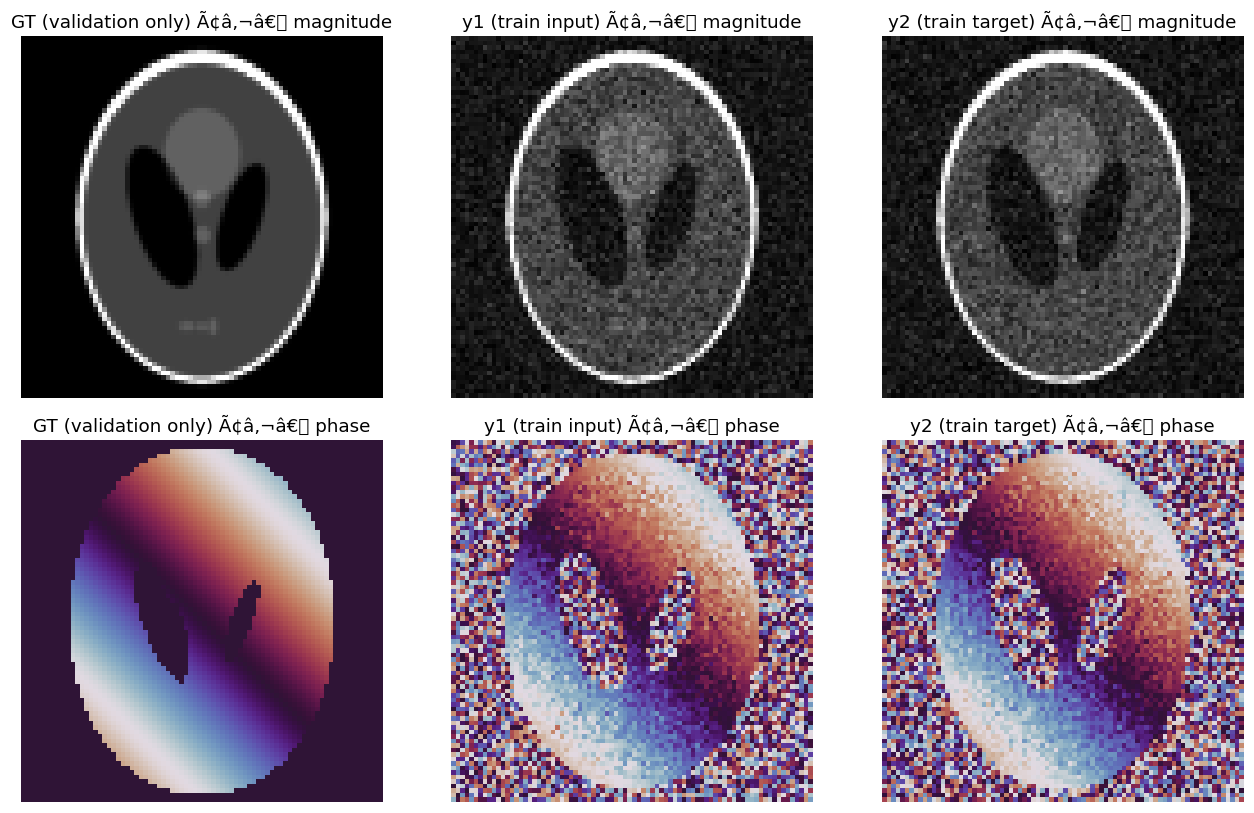

noise correlation (y1,y2 noise fields): 0.0079


In [31]:
# Visual: GT, y1, y2 magnitude + phase so the independence/noise level is clear.
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
cols = ["GT (validation only)", "y1 (train input)", "y2 (train target)"]
for col, img in enumerate([gt_norm, y1, y2]):
    axes[0, col].imshow(torch.abs(img).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"{cols[col]} Ã¢â‚¬â€ magnitude"); axes[0, col].axis("off")
    axes[1, col].imshow(torch.angle(img).numpy(), cmap="twilight",
                        vmin=-np.pi, vmax=np.pi)
    axes[1, col].set_title(f"{cols[col]} Ã¢â‚¬â€ phase"); axes[1, col].axis("off")
fig.tight_layout()
plt.show()

# Numerical: the two noise draws should be independent (uncorrelated).
print("noise correlation (y1,y2 noise fields):",
      f"{(_n1.conj() * _n2).abs().mean().item():.4f}")

## 2. Convert to 2-channel and sanity-check per-channel stats

The network consumes **2-channel Real/Imag** images. We build the N2N ***training***
representation as a `(B, 4, H, W)` stack: channels `[b, 0:2]` = y1 (the perturbed
input), channels `[b, 2:4]` = y2 (the regression target). `di_n2n.pack_pair` makes
this stack, and the N2N forms slice the two halves internally.

In [32]:
BATCH = 4                       # only the diagnostic pair below; training re-samples fresh pairs
y1_two = complex_to_two_ch(y1).to(DEVICE)     # (1, 2, H, W)
y2_two = complex_to_two_ch(y2).to(DEVICE)     # (1, 2, H, W)

# Repeat to a minibatch and pack the (y1, y2) pair side-by-side in channels.
y1_b = y1_two.repeat(BATCH, 1, 1, 1)
y2_b = y2_two.repeat(BATCH, 1, 1, 1)
pair = pack_pair(y1_b, y2_b)   # (B, 4, H, W) -- DIAGNOSTIC only: stats/existence check, NOT used for training
print("pair shape:", tuple(pair.shape),
      "| [0:2]=y1 input, [2:4]=y2 target")

# Per-channel effective scale of the INPUT half the network sees (matches demo).
print("y1 per-channel stats ([Re, Im]) the net sees:")
for name, ch in zip(["Re", "Im"], y1_two[0]):
    print(f"  {name}: mean = {ch.mean().item():+.3f}, std = {ch.std().item():.3f}, "
          f"min = {ch.min().item():+.3f}, max = {ch.max().item():+.3f}")

# Same for the target half (should have identical stats; they're both noisy phantoms).
print("y2 per-channel stats (target):")
for name, ch in zip(["Re", "Im"], y2_two[0]):
    print(f"  {name}: mean = {ch.mean().item():+.3f}, std = {ch.std().item():.3f}")

pair shape: (4, 4, 80, 80) | [0:2]=y1 input, [2:4]=y2 target
y1 per-channel stats ([Re, Im]) the net sees:
  Re: mean = -0.023, std = 0.229, min = -1.360, max = +1.355
  Im: mean = +0.010, std = 0.195, min = -1.288, max = +1.358
y2 per-channel stats (target):
  Re: mean = -0.023, std = 0.230
  Im: mean = +0.011, std = 0.197


**Config is re-aligned for the N2N task** (unlike the broad generative defaults from `demo.ipynb`):
  - DDPM: T=200, beta=(1e-4, **5e-4**) — a TIGHT schedule so the Tweedie gain `1/sqrt(alpha_bar)` stays ≈1 over the trained `t` (a wide beta_end amplifies the decode error up to 2.75× and ill-conditions image regression).
  - DSM: L levels over sigma in **[1/SNR, 4/SNR]** — the range tied to the REAL task noise floor (sigma_min = task sigma, sigma_max a few σ above), so the anneal never wanders under the noise floor (replaces the generative 0.01..0.66).
  - same `GRAD_CLIP`, same `lr`, same seed.

In [33]:
GRAD_CLIP = 1.0
LR        = 1e-3

# ---- Schedule alignment for the N2N task (decode conditioning) -------------
# N2N regresses an IMAGE (Tweedie x0_hat vs the real noisy phantom), so the
# forward schedule must keep the Tweedie gain 1/sqrt(alpha_bar) ~ 1 over the
# trained t. BUT the diffuse-then-reverse sampler must also be able to place
# the noisy map at a rung whose added-noise std sqrt(1 - alpha_bar_{t_eff})
# sits SLIGHTLY ABOVE the task sigma sigma_task = ref_mag/SNR. The old tight
# beta_end=5e-4 capped sigma_max at 0.241, which is unreachable for the target
# scenario (real SNR can be 10 or less -- sigma_task down to 0.333 at SNR 3).
# We therefore widen beta_end to 1e-2 -> sigma_max = 0.798, covering sigma_task
# all the way to SNR ~2 while keeping 1/sqrt(alpha_bar_t) modest (~1.25 at the
# highest t actually used for the decode).
T_N2N       = 200
BETA_START  = 1e-4
BETA_END    = 1e-2          # wide enough for the diffuse-to rung at low SNR; 1/sqrt(alpha_bar)~1.25
REWEIGHT_T  = False

# ---- DSM sigma range tied to the REAL data's noise floor -------------------
# task sigma = ref_mag/SNR (= 1/SNR here, ref_mag=1). sigma_min is pinned to the
# task sigma so the anneal never wanders under the noise floor; sigma_max sits a
# few sigma ABOVE task sigma to cover the diffusion noise AND leave the anneal
# real recovery distance (the conditional sampler seeds at sigma_ratio*sigma_task
# and walks DOWN to sigma_min, so sigma_max must be high enough that the seeded
# rung is well up the 20-level ladder -- see the A/B cell).
TASK_SIGMA  = 1.0 / SNR
DSM_SIGMA_MIN = TASK_SIGMA             # floor = task sigma (nothing below to denoise)
DSM_SIGMA_MAX = 8.0 * TASK_SIGMA       # 8x the task noise -> wide ladder so the anneal has levels to descend
DSM_L         = 20

# ---- DDPM-backbone N2N ----
cdpm_backbone = UNet(in_ch=2, out_ch=2, base_out=32, emb_dim=32).to(DEVICE)
n2n_ddpm = N2N_DDPM(T=T_N2N, beta_start=BETA_START, beta_end=BETA_END,
                    backbone=cdpm_backbone, endpoint=0.0, reweight_t=REWEIGHT_T)
trainer_ddpm = DiffusionTrainer(n2n_ddpm, lr=LR, device=DEVICE,
                                grad_clip=GRAD_CLIP)
print(f"N2N_DDPM params: {sum(p.numel() for p in n2n_ddpm.net.parameters()):,},"
      f" T={n2n_ddpm.ddpm.T}, beta_end={BETA_END:.4f}, reweight_t={REWEIGHT_T}")
print("sigma_max (diffuse-to rung capacity):",
      f"{n2n_ddpm.ddpm.sqrt_one_minus_alpha_bar[-1].item():.4f}")

# ---- DSM-backbone N2N (sigma range aligned to the task noise floor) ----
sdsm_backbone = UNet(in_ch=2, out_ch=2, base_out=32, emb_dim=32).to(DEVICE)
n2n_dsm = N2N_DSM(L=DSM_L, sigma_min=DSM_SIGMA_MIN, sigma_max=DSM_SIGMA_MAX,
                  backbone=sdsm_backbone, task_sigma=TASK_SIGMA)
trainer_dsm = DiffusionTrainer(n2n_dsm, lr=LR, device=DEVICE,
                               grad_clip=GRAD_CLIP)
print(f"N2N_DSM params: {sum(p.numel() for p in n2n_dsm.net.parameters()):,}, L={n2n_dsm.dsm.L},"
      f" task_sigma={TASK_SIGMA:.4f}, sigma range=[{DSM_SIGMA_MIN:.4f}, {DSM_SIGMA_MAX:.4f}]")

N2N_DDPM params: 6,630,306, T=200, beta_end=0.0100, reweight_t=False
sigma_max (diffuse-to rung capacity): 0.7981
N2N_DSM params: 6,630,306, L=20, task_sigma=0.1000, sigma range=[0.1000, 0.8000]


## 4. Train both N2N models (Regime B: fresh pairs every iteration)

Each iteration feeds a freshly-resynthesized packed pair to `DiffusionTrainer.step`,
which calls `loss(x0, rng=rng)`. Inside, `N2N_DDPM.loss` / `N2N_DSM.loss` perturb
the y1 half, Tweedie-decode `x0_hat`, and regress it onto the y2 half.

**Regime-B pair source (`draw_pair_batch`):** because we have a clean `gt` phantom,
each `step` draws a brand-new INDEPENDENT `(y1, y2)` pair from `gt_norm` at the
target SNR. The model therefore sees thousands of distinct noise realizations and
learns the clean image in expectation -- with zero risk of memorizing one frozen
pair. (This is the finite-pool problem we will *not* have here; a fixed finite
pool of real pairs, sampled per batch, is the regime we will build next for real
data.) Same seed for both backbones so the A/B is apples-to-apples.

[DDPM-N2N] iter   100 | loss = 0.0218
[DDPM-N2N] iter   200 | loss = 0.0065
[DDPM-N2N] iter   300 | loss = 0.0079
[DDPM-N2N] iter   400 | loss = 0.0053
[DDPM-N2N] iter   500 | loss = 0.0068
[DDPM-N2N] iter   600 | loss = 0.0054
[DDPM-N2N] iter   700 | loss = 0.0045
[DDPM-N2N] iter   800 | loss = 0.0040
[DDPM-N2N] iter   900 | loss = 0.0034
[DDPM-N2N] iter  1000 | loss = 0.0029
[DDPM-N2N] iter  1100 | loss = 0.0028
[DDPM-N2N] iter  1200 | loss = 0.0030
[DDPM-N2N] iter  1300 | loss = 0.0031
[DDPM-N2N] iter  1400 | loss = 0.0027
[DDPM-N2N] iter  1500 | loss = 0.0028
[DDPM-N2N] iter  1600 | loss = 0.0028
[DDPM-N2N] iter  1700 | loss = 0.0026
[DDPM-N2N] iter  1800 | loss = 0.0028
[DDPM-N2N] iter  1900 | loss = 0.0028
[DDPM-N2N] iter  2000 | loss = 0.0030
[DDPM-N2N] iter  2100 | loss = 0.0024
[DDPM-N2N] iter  2200 | loss = 0.0028
[DDPM-N2N] iter  2300 | loss = 0.0028
[DDPM-N2N] iter  2400 | loss = 0.0027
[DDPM-N2N] iter  2500 | loss = 0.0024
[DDPM-N2N] iter  2600 | loss = 0.0032
[DDPM-N2N] i

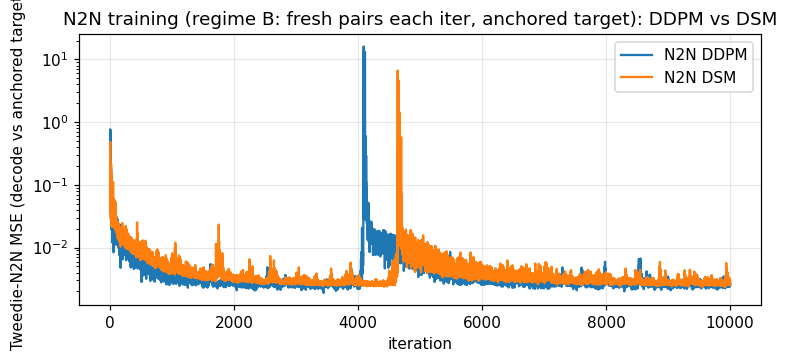

In [34]:
# ============================================================================
# 4. Train both N2N models on REGIME-B: fresh independent pairs every iteration
# ============================================================================
# Objective (both backbones): ANCHORED-target N2N. Per batch element the pair is
# `pack_pair(y1, y2)` = (B,4,H,W). `loss` draws t / i_vec, Shuffles which half is
# the perturbed/decode input, Tweedie-decodes x0_hat, and regresses it onto the
# ANCHORED target (y1+y2)/2 -- whose conditional mean over pairs is the clean gt.
# This replaces the old `x0_hat -> y2` objective (structurally unreachable, gave
# no gradient toward gt); the half-shuffle keeps the objective symmetric.
#
# Pair source: we have clean `gt_norm`, so each `step` draws a brand-new
# independent (y1, y2) pair via `draw_pair_batch`. Same seed for both backbones
# so the A/B is apples-to-apples.

N_ITERS   = 10000
LOG_EVERY = 100
BATCH     = 4                       # fresh independent pairs drawn per iteration

all_losses = {}

# ---- train N2N_DDPM ---- (fresh pairs from `gt_norm` at the target SNR)
torch.manual_seed(0)
n2n_ddpm.net.train()
lss = []
for it in range(N_ITERS):
    pair = draw_pair_batch(gt_norm, SNR, batch=BATCH, device=DEVICE)
    loss = trainer_ddpm.step(pair)
    lss.append(loss)
    if (it + 1) % LOG_EVERY == 0:
        print(f"[DDPM-N2N] iter {it + 1:>5} | loss = {loss:.4f}")
all_losses["ddpm"] = lss

# ---- train N2N_DSM ---- (same fresh-pair regime, same seed -> apples-to-apples)
torch.manual_seed(0)
n2n_dsm.net.train()
lss = []
for it in range(N_ITERS):
    pair = draw_pair_batch(gt_norm, SNR, batch=BATCH, device=DEVICE)
    loss = trainer_dsm.step(pair)
    lss.append(loss)
    if (it + 1) % LOG_EVERY == 0:
        print(f"[DSM-N2N] iter {it + 1:>5} | loss = {loss:.4f}")
all_losses["dsm"] = lss

# ---- plot both on the same log-y axes ----
plt.figure(figsize=(8, 3.2))
for tag, lss in all_losses.items():
    plt.plot(lss, label=f"N2N {tag.upper()}")
plt.xlabel("iteration"); plt.ylabel("Tweedie-N2N MSE (decode vs anchored target)")
plt.title("N2N training (regime B: fresh pairs each iter, anchored target): DDPM vs DSM")
plt.yscale("log"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [35]:
# Simple per-model trainer-side RMSE helper for the validation cells below.
import torch as _t
def nmse(a, b):
    a = a.abs(); b = b.abs()
    return ((a - b).square().mean() / b.square().mean()).item()
def rmse(a, b):
    return (a.abs() - b.abs()).square().mean().sqrt().item()
print("metrics helper defined")

metrics helper defined


In [68]:
# ---- TEMPORARY: transfer the trained N2N_DSM weights onto a NEW instance ----
# The `N2N_DSM` class in n2n.py was EDITED (new `conditional_denoise` signature
# with sigma_task / sigma_ratio) AFTER the build cell instantiated and trained
# `n2n_dsm`. The in-memory object is therefore a stale instance of the OLD class
# (which is why the A/B cell raised `TypeError: unexpected keyword 'sigma_task'`).
# Rebuild a fresh instance from the UPDATED class (hyperparams/backbone match the
# build cell) and copy the trained weights across, then rebind `n2n_dsm`.

n2n_dsm_new = N2N_DSM(L=DSM_L, sigma_min=DSM_SIGMA_MIN, sigma_max=DSM_SIGMA_MAX,
                      backbone=UNet(in_ch=2, out_ch=2, base_out=32,
                                    emb_dim=32).to(DEVICE),
                      task_sigma=TASK_SIGMA)
n2n_dsm_new.net.load_state_dict(n2n_dsm.net.state_dict())
n2n_dsm = n2n_dsm_new
trainer_dsm = DiffusionTrainer(n2n_dsm, lr=LR, device=DEVICE, grad_clip=GRAD_CLIP)
print("transferred trained N2N_DSM weights -> updated class instance")

transferred trained N2N_DSM weights -> updated class instance


## 5. A/B validation: conditional denoise of a held-out noisy phantom

Build a **held-out** noisy phantom `y_val` (yet another independent realization of
`gt`, never used in training), then decode it with each trained N2N model's
`conditional_denoise`. Compare the recovered magnitude against the **never-seen**
clean `gt` (validation only), reporting RMSE/NMSE for DDPM vs DSM.

validation noisy phantom drawn (seed 99).
RMSE(DDPM) vs gt: 0.0338   NMSE: 0.0139
RMSE(DSM)  vs gt: 0.0358   NMSE: 0.0156
RMSE(noisy val)  vs gt: 0.0874   (reference: no denoise)


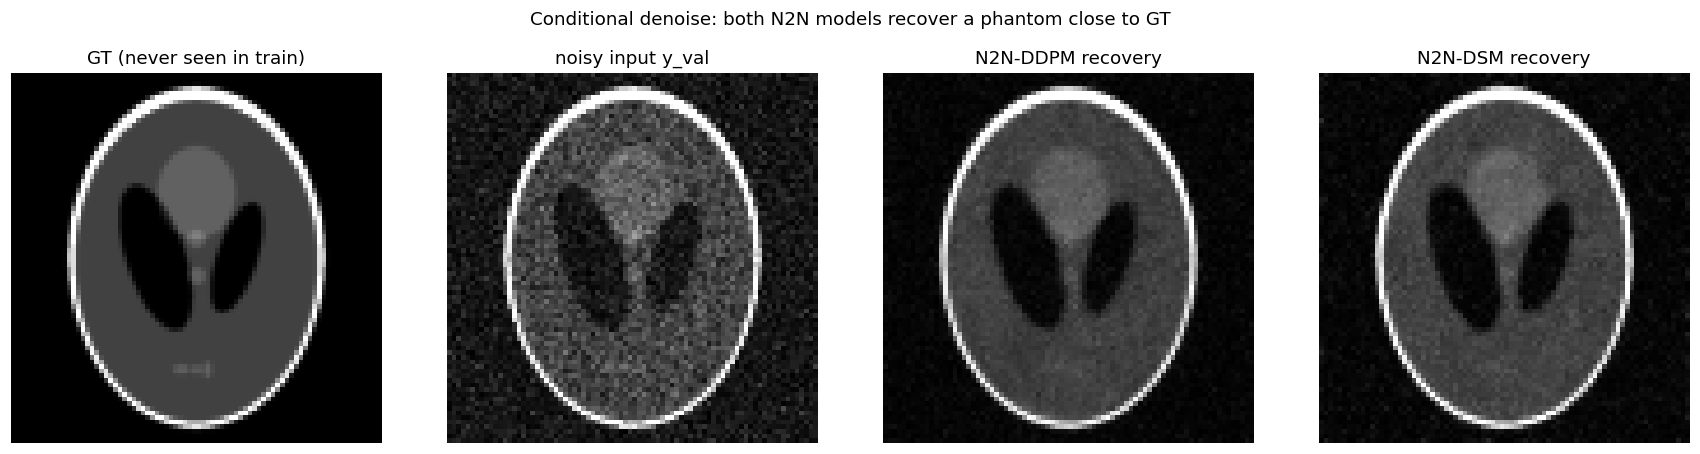

In [70]:
# Held-out noisy realization (validation input).
VSNR = SNR
y_val, _nv = add_complex_noise(gt_norm, VSNR, seed=99)
y_val_two = complex_to_two_ch(y_val).to(DEVICE)
val_in = y_val_two.view(1, 2, *y_val_two.shape[-2:])
print("validation noisy phantom drawn (seed 99).")

# ---- DDPM conditional denoise: diffuse-then-reverse (deterministic DDIM) ----
# The new sampler places the noisy map at the rung whose added-noise std is
# SIGMA_RATIO * sigma_task (sigma_task = ref_mag/VSNR), then runs a deterministic
# DDIM reverse walk t_eff -> 0. SIGMA_RATIO > 1 keeps the diffuse-to rung just
# ABOVE the map's own noise so there is real reverse-walk distance to denoise.
n2n_ddpm.net.eval()
sigma_task = 1.0 / VSNR                 # acquired noise level of y_val (ref_mag=1)
SIGMA_RATIO = 1.5
DDIM_STEPS = 50
with torch.no_grad():
    rec_ddpm = n2n_ddpm.conditional_denoise(val_in, sigma_task=sigma_task,
                                            sigma_ratio=SIGMA_RATIO,
                                            num_steps=DDIM_STEPS, device=DEVICE)
rec_ddpm = two_ch_to_complex(rec_ddpm).cpu()

# ---- DSM conditional denoise: diffuse-then-refine Langevin seeded by noisy map ----
# The map y = gt + sigma_task*eps is first DIFFUSED up to sigma_ratio*sigma_task
# (y' = y + sqrt(sigma_ratio^2 - 1)*sigma_task*w, so Var(noise) -> (ratio*sigma)^2),
# then refined with a predictor-to-Tweedie anneal. Unlike a pure Langevin walk the
# corrector moves the map a FRACTION along the local clean-Tweedie residual
# (ref = x + s^2*score) at each level rather than re-injecting unit noise, so the
# final iterate is closer to clean than the seed (the old NMSE~4116 blowup / worse-
# than-input failure). CORRECTOR_ALPHA is that fraction (units of s^2). Tuned with
# the widened DSM_SIGMA_MAX=0.8 so the seeded rung (sigma_ratio*sigma_task) sits
# well up the ladder -- providing real reverse-walk distance to descend.
n2n_dsm.net.eval()
sigma_task = 1.0 / VSNR                   # acquired noise level of y_val (ref_mag=1)
SIGMA_RATIO_DSM = 1.5
CORRECTOR_ALPHA = 0.2
CORRECTOR_STEPS = 5
with torch.no_grad():
    rec_dsm = n2n_dsm.conditional_denoise(val_in, sigma_task=sigma_task,
                                          sigma_ratio=SIGMA_RATIO_DSM,
                                          eps=0,
                                          corrector_alpha=CORRECTOR_ALPHA,
                                          corrector_steps=CORRECTOR_STEPS,
                                          device=DEVICE)
rec_dsm = two_ch_to_complex(rec_dsm).cpu()

gt_cpu = gt_norm.unsqueeze(0).cpu()
print(f"RMSE(DDPM) vs gt: {rmse(rec_ddpm, gt_cpu):.4f}   NMSE: {nmse(rec_ddpm, gt_cpu):.4f}")
print(f"RMSE(DSM)  vs gt: {rmse(rec_dsm,  gt_cpu):.4f}   NMSE: {nmse(rec_dsm,  gt_cpu):.4f}")
print(f"RMSE(noisy val)  vs gt: {rmse(y_val.unsqueeze(0).cpu(), gt_cpu):.4f}   (reference: no denoise)")

# ---- render: GT | noisy input | DDPM recovery | DSM recovery (magnitude) ----
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, title, img in [
        (axes[0], "GT (never seen in train)", gt_cpu[0]),
        (axes[1], "noisy input y_val", y_val),
        (axes[2], "N2N-DDPM recovery", rec_ddpm[0]),
        (axes[3], "N2N-DSM recovery", rec_dsm[0])]:
    ax.imshow(img.abs().numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title); ax.axis("off")
fig.suptitle("Conditional denoise: both N2N models recover a phantom close to GT", y=1.02)
fig.tight_layout()
plt.show()

### DDIM reuse on the trained DDPM net

The `N2N_DDPM.conditional_denoise` above used `sample_ddim` with `num_steps=50`
(deterministic `eta=0`). This cell sweeps the DDIM step count on the SAME trained
net Ã¢â‚¬â€ showing the deterministic few-step decoder recovers a clean image even at
very few steps. No retraining: DDIM consumes the identical DDPM weights.

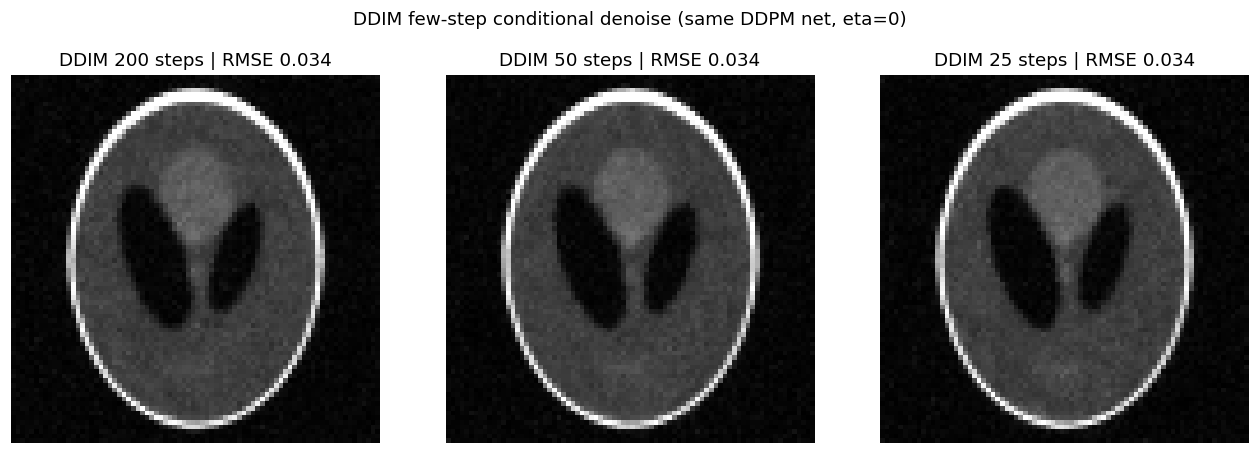

In [38]:
DDIM_SWEEP = [200, 50, 25]
plt.figure(figsize=(4 * len(DDIM_SWEEP), 4))
with torch.no_grad():
    for k, ns in enumerate(DDIM_SWEEP):
        rec = n2n_ddpm.conditional_denoise(val_in, sigma_task=sigma_task,
                                           sigma_ratio=SIGMA_RATIO,
                                           num_steps=ns, device=DEVICE)
        rec = two_ch_to_complex(rec).cpu()
        ax = plt.subplot(1, len(DDIM_SWEEP), k + 1)
        ax.imshow(rec[0].abs().numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"DDIM {ns} steps | RMSE {rmse(rec, gt_cpu):.3f}")
        ax.axis("off")
plt.suptitle("DDIM few-step conditional denoise (same DDPM net, eta=0)", y=1.02)
plt.tight_layout()
plt.show()

In [72]:
# ---- Save the trained N2N models as (state_dict + cfg) dicts ----------------
# We save a plain dict of the UNet weights + the container config, NOT the whole
# Python object. torch.save(whole_object) pickles the CLASS reference, which breaks
# after the importlib.reload above ("not the same object as n2n.N2N_DDPM"
# PicklingError). A dict pickles clean, survives reload, and still lets us rebuild
# the full ready-to-sample container on load (the cfg carries the schedule so the
# score/level net is self-describing).
import os

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

def save_n2n(path, net, cfg, tag):
    torch.save({"state_dict": net.state_dict(), "cfg": cfg, "net_type": tag},
               path)
    print(f"saved {tag:>8} -> {path}  ({os.path.getsize(path) / 1e6:.2f} MB)")

# DDPM-neck container: schedule the N2N_DDPM was built with.
save_n2n(SAVE_DIR / "shepp_ddpm_n2n_ddpm_it10000.pt", n2n_ddpm.net,
         {"T": T_N2N, "beta_start": BETA_START, "beta_end": BETA_END,
          "reweight_t": REWEIGHT_T, "endpoint": 0.0}, "N2N_DDPM")

# DSM-neck container: sigma ladder the N2N_DSM was built with.
save_n2n(SAVE_DIR / "shepp_ddpm_n2n_dsm_it10000.pt", n2n_dsm.net,
         {"L": DSM_L, "sigma_min": DSM_SIGMA_MIN, "sigma_max": DSM_SIGMA_MAX,
          "task_sigma": TASK_SIGMA}, "N2N_DSM")

saved N2N_DDPM -> saved_models\shepp_ddpm_n2n_ddpm_it10000.pt  (26.56 MB)
saved  N2N_DSM -> saved_models\shepp_ddpm_n2n_dsm_it10000.pt  (26.56 MB)


In [ ]:
# ---- Load a saved N2N model back into a ready-to-sample container -------------
# Rebuilds the full N2N container from the cfg stored alongside the weights, so a
# saved model is self-describing: the schedule (T/beta or L/sigma ladder) plus the
# task_sigma come straight back from the dict, no need to re-type knobs. The UNet
# backbone is recreated by hand (in_ch=2, out_ch=2, base_out=32, emb_dim=32 to match
# the build cell), then load_state_dict drops the saved weights in, and .eval()
# readies it for scoring/sampling.
def load_n2n(path, device="cpu"):
    blob = torch.load(path, map_location=device)
    net_type, cfg = blob["net_type"], blob["cfg"]
    bb = UNet(in_ch=2, out_ch=2, base_out=32, emb_dim=32).to(device)
    if net_type == "N2N_DDPM":
        net = N2N_DDPM(T=cfg["T"], beta_start=cfg["beta_start"],
                       beta_end=cfg["beta_end"], backbone=bb,
                       endpoint=cfg.get("endpoint", 0.0),
                       reweight_t=cfg.get("reweight_t", False))
    elif net_type == "N2N_DSM":
        net = N2N_DSM(L=cfg["L"], sigma_min=cfg["sigma_min"],
                      sigma_max=cfg["sigma_max"], backbone=bb,
                      task_sigma=cfg["task_sigma"])
    else:
        raise ValueError(f"unknown net_type: {net_type!r}")
    net.net.load_state_dict(blob["state_dict"])
    net.net.eval()
    print(f"loaded {net_type} from {path}  (cfg: {cfg})")
    return net, cfg

n2n_ddpm_loaded = load_n2n(SAVE_DIR / "shepp_ddpm_n2n_ddpm_it10000.pt", device=DEVICE)[0]
n2n_dsm_loaded  = load_n2n(SAVE_DIR / "shepp_ddpm_n2n_dsm_it10000.pt",  device=DEVICE)[0]

## 6. Optional: unconditional generation

The same N2N models also act as generative diffusion models when run from pure
noise (no conditioning): `N2N_DDPM.unconditional` decodes noise Ã¢â€ â€™ phantom via the
DDPM reverse walk; `N2N_DSM.unconditional` runs the annealed Langevin walk.

DDPM-GEN RMSE vs gt: 0.2651
DSM-GEN  RMSE vs gt: nan


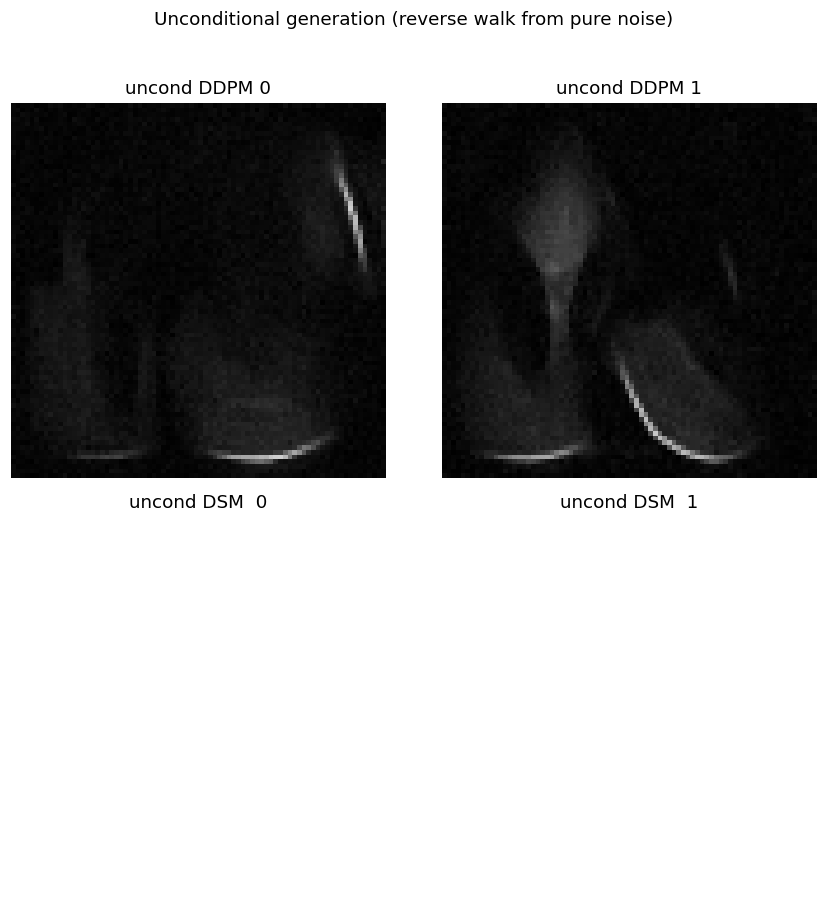

In [83]:
N_GEN = 2
shape = (N_GEN, 2) + tuple(y_val_two.shape[-2:])

torch.manual_seed(0)
with torch.no_grad():
    g_ddpm = n2n_ddpm.unconditional(shape, steps=n2n_ddpm.ddpm.T, device=DEVICE)
g_ddpm = two_ch_to_complex(g_ddpm).cpu()

torch.manual_seed(0)
with torch.no_grad():
    g_dsm = n2n_dsm.unconditional(shape, device=DEVICE)
g_dsm = two_ch_to_complex(g_dsm).cpu()

print(f"DDPM-GEN RMSE vs gt: {rmse(g_ddpm, gt_cpu):.4f}")
print(f"DSM-GEN  RMSE vs gt: {rmse(g_dsm,  gt_cpu):.4f}")

fig, axes = plt.subplots(2, N_GEN, figsize=(4 * N_GEN, 8))
for j in range(N_GEN):
    axes[0, j].imshow(g_ddpm[j].abs().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"uncond DDPM {j}"); axes[0, j].axis("off")
    axes[1, j].imshow(g_dsm[j].abs().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title(f"uncond DSM  {j}"); axes[1, j].axis("off")
fig.suptitle("Unconditional generation (reverse walk from pure noise)", y=1.02)
fig.tight_layout()
plt.show()